(introduction)=
# Introduction to PTGP

PTGP builds Gaussian process models on [PyTensor](https://pytensor.readthedocs.io) and [PyMC](https://www.pymc.io): you define a kernel, put PyMC priors on its hyperparameters, and PTGP compiles the linear algebra into a function you fit and predict with in two calls.

This guide fits an exact GP to a small regression dataset, shows what {func}`pg.fit <ptgp.optim.fit>` and {func}`pg.predict <ptgp.optim.predict>` do underneath, and swaps in a sparse VFE approximation. Minibatch training, non-Gaussian likelihoods, SVGP, and Variational Fourier Features are covered in the {ref}`companion notebook <gp-variational-stochastic>`. See the {doc}`kernel gallery </kernels/gallery>` for covariance functions and the {doc}`user guide </user_guide/index>` for the full API.

It assumes you know Gaussian processes and are comfortable with PyMC.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import ptgp as pg


plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "figure.dpi": 144,
        "figure.constrained_layout.use": True,
        "axes.grid": True,
        "grid.linewidth": 0.5,
        "grid.linestyle": "--",
    }
)

## The data

The Silverman motorcycle dataset: 133 accelerometer readings from a crash-test dummy's head during a simulated impact, pairing time since impact (ms) with head acceleration (g). The response is smooth but sharply varying, and the noise grows after impact.

We standardize both axes so the priors below are sensibly scaled, and de-standardize when plotting.

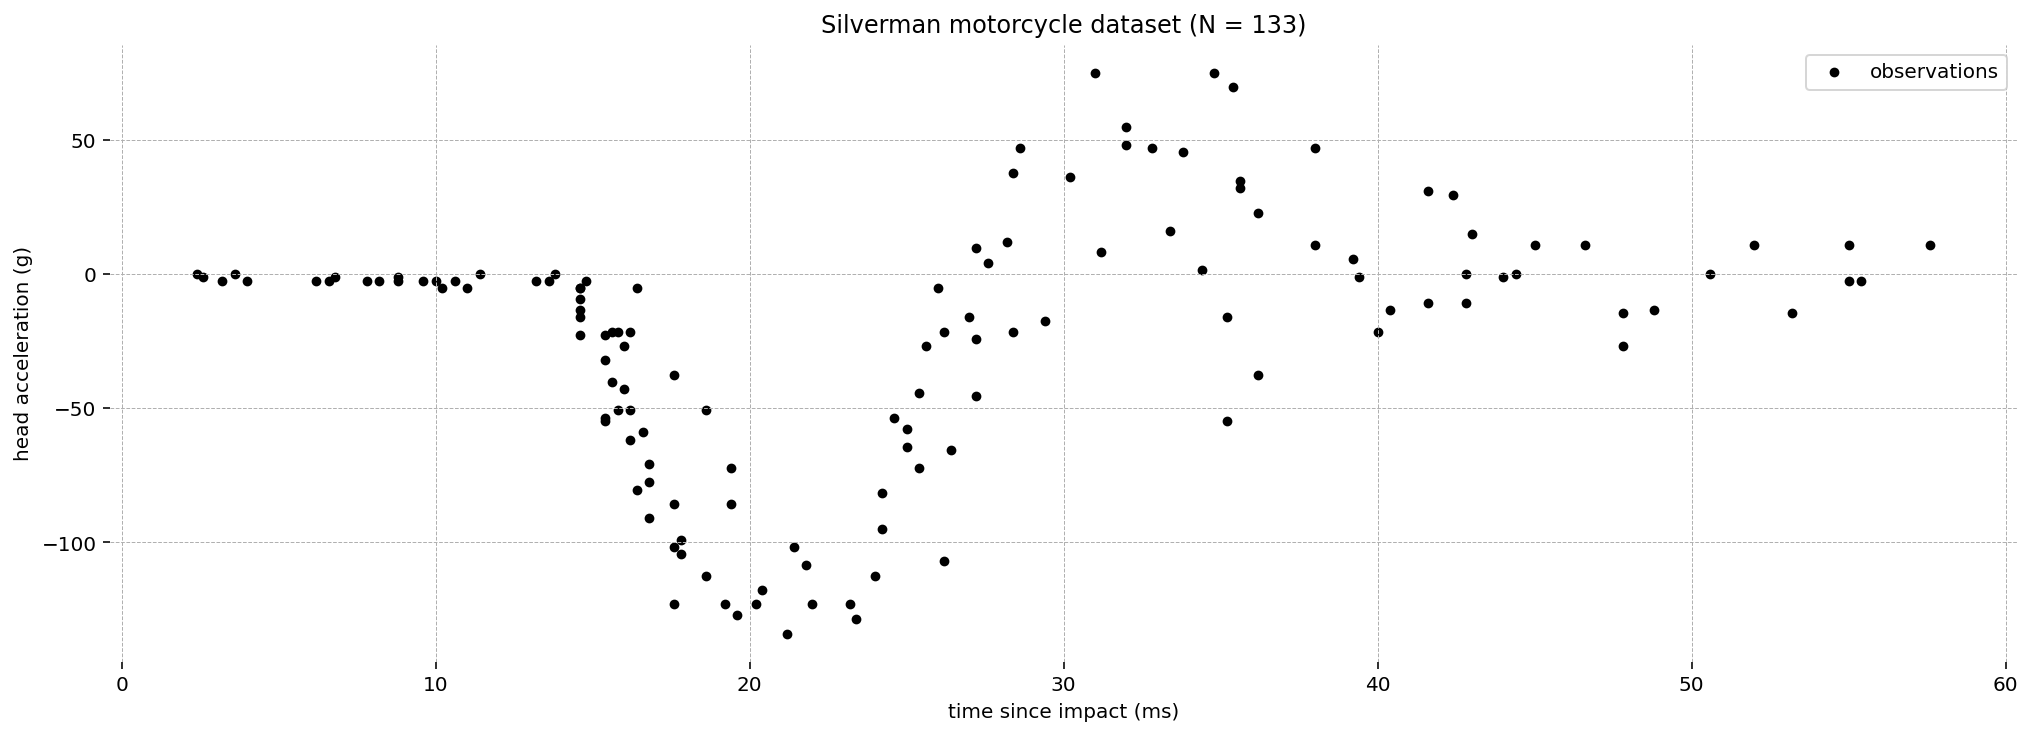

In [21]:
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MASS/mcycle.csv"
csv_path = Path("mcycle.csv")
if not csv_path.exists():
    pd.read_csv(url).to_csv(csv_path, index=False)  # cache locally; don't refetch each run
mcycle = pd.read_csv(csv_path)

t = mcycle["times"].to_numpy(float)  # time since impact (ms)
a = mcycle["accel"].to_numpy(float)  # head acceleration (g)

x_scaler = StandardScaler().fit(t[:, None])
y_scaler = StandardScaler().fit(a[:, None])
X = x_scaler.transform(t[:, None])
y = y_scaler.transform(a[:, None]).ravel()
N = X.shape[0]

# Dense prediction grid in standardized space, plus its physical-unit times.
X_grid = np.linspace(X.min() - 0.2, X.max() + 0.2, 200)[:, None]
t_grid = x_scaler.inverse_transform(X_grid).ravel()

fig, ax = plt.subplots()
ax.scatter(t, a, s=15, c="k", label="observations")
ax.set_xlabel("time since impact (ms)")
ax.set_ylabel("head acceleration (g)")
ax.set_title(f"Silverman motorcycle dataset (N = {N})")
ax.legend()
plt.show()

In [27]:
def to_g(y_std):
    """Map standardized acceleration values back to g (physical units)."""
    return y_scaler.inverse_transform(np.reshape(y_std, (-1, 1))).ravel()


def plot_gp(
    mean,
    f_band,
    y_band=None,
    *,
    ax=None,
    color="C0",
    ls="-",
    label="posterior mean",
    inducing=None,
    title=None,
    band_labels=True,
):
    """Plot a GP posterior over the data: mean, function band, and optional noise band."""
    if ax is None:
        _, ax = plt.subplots()
        ax.scatter(t, a, s=15, c="k", zorder=3, label="observations")
        ax.set_xlabel("time since impact (ms)")
        ax.set_ylabel("head acceleration (g)")
    ax.plot(t_grid, mean, color=color, ls=ls, lw=2, label=label)
    if y_band is not None:
        ax.fill_between(
            t_grid,
            *y_band,
            color=color,
            alpha=0.12,
            label="observation ±2 sd" if band_labels else None,
        )
    ax.fill_between(
        t_grid, *f_band, color=color, alpha=0.25, label="function ±2 sd" if band_labels else None
    )
    if inducing is not None:
        ax.scatter(
            inducing,
            np.full(len(inducing), a.min() - 5),
            marker="^",
            c="r",
            s=45,
            zorder=4,
            label=f"inducing inputs (M = {len(inducing)})",
        )
    if title:
        ax.set_title(title)
    ax.legend(loc="lower right")
    return ax

## Exact GP

The model is a zero mean, a {class}`Matérn 5/2 <ptgp.kernels.Matern52>` kernel scaled by an amplitude $\eta^2$, and Gaussian observation noise $\sigma$. The hyperparameters are PyMC random variables, so priors go on them the usual way.

{class}`pg.gp.Unapproximated <ptgp.gp.Unapproximated>` is the exact GP. {func}`pg.fit <ptgp.optim.fit>` optimizes the hyperparameters to their MAP values (marginal likelihood plus PyMC log-prior, L-BFGS-B) and returns a {class}`FitResult <ptgp.optim.FitResult>` that {func}`pg.predict <ptgp.optim.predict>` consumes.

In [22]:
with pm.Model() as exact_model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    eta = pm.Exponential("eta", scale=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    kernel = eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls)
    gp = pg.gp.Unapproximated(kernel=kernel, sigma=sigma)

    fit = pg.fit(gp, X, y)

for name, value in fit.params.items():
    print(f"{name:>6} = {value:.3f}")

    ls = 0.475
   eta = 0.909
 sigma = 0.471


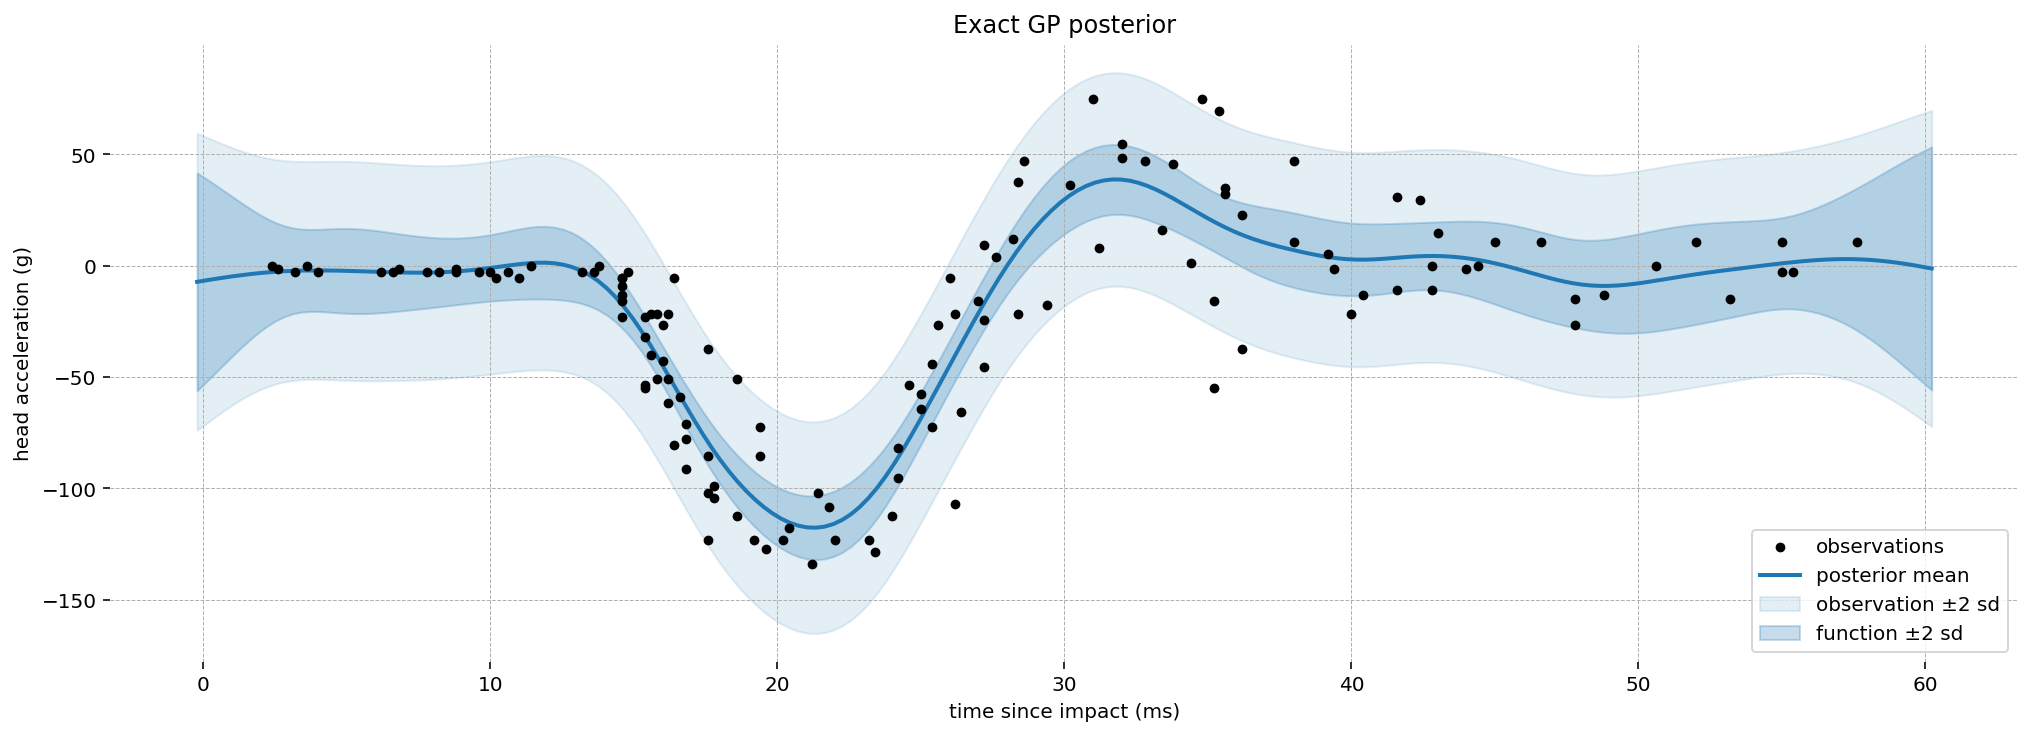

In [28]:
mu, var = pg.predict(gp, X_grid, fit, X_train=X, y_train=y)
_, var_y = pg.predict(gp, X_grid, fit, X_train=X, y_train=y, incl_lik=True)

sd, sd_y = np.sqrt(var), np.sqrt(var_y)
mean = to_g(mu)
f_band = to_g(mu - 2 * sd), to_g(mu + 2 * sd)  # latent function f
y_band = to_g(mu - 2 * sd_y), to_g(mu + 2 * sd_y)  # predictive, for a new observation y

plot_gp(mean, f_band, y_band, title="Exact GP posterior")
plt.show()

The inner band is the posterior over the latent function $f$; the outer band adds observation noise and predicts a new $y$. The function band is tight where data is dense and widens past the edges.

The Gaussian likelihood assumes constant noise, but this data is heteroscedastic (quiet before impact, noisy after), so the noise band runs too wide early and too narrow late. Input-dependent noise needs a non-Gaussian likelihood or a kernel like {class}`Gibbs <ptgp.kernels.Gibbs>`; see the companion notebook.

## Under the hood

{func}`pg.fit <ptgp.optim.fit>` and {func}`pg.predict <ptgp.optim.predict>` wrap a lower-level API. For a custom optimizer, frozen variables, or staged training, call the pieces directly: {func}`~ptgp.optim.compile_scipy_objective` builds the loss and gradient, you run any optimizer, and {func}`~ptgp.optim.get_trained_params` reads the result back. This reproduces the fit above.

In [25]:
import scipy.optimize

X_var = pt.matrix("X", shape=(None, 1))
y_var = pt.vector("y", shape=(None,))

with pm.Model() as manual_model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    eta = pm.Exponential("eta", scale=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    gp_manual = pg.gp.Unapproximated(
        kernel=eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls), sigma=sigma
    )
    fun, theta0, unpack, shared_params, _ = pg.optim.compile_scipy_objective(
        pg.objectives.marginal_log_likelihood, gp_manual, X_var, y_var
    )

result = scipy.optimize.minimize(fun, theta0, args=(X, y), jac=True, method="L-BFGS-B")
unpack(result.x)

params = pg.optim.get_trained_params(manual_model, shared_params)
print({name: round(float(v), 3) for name, v in params.items()})

{'ls': 0.475, 'eta': 0.909, 'sigma': 0.471}


## Sparse GP (VFE)

Exact inference factorizes an $N \times N$ matrix: $O(N^3)$ time, $O(N^2)$ memory. Sparse GPs summarize the data with $M \ll N$ inducing points; the VFE bound {cite:p}`titsias-2009` fits them at $O(N M^2)$ while staying close to exact inference.

{class}`pg.gp.VFE <ptgp.gp.VFE>` takes an `inducing_variable`. {func}`~ptgp.inducing.greedy_variance_init` places the inducing inputs by pivoted Cholesky {cite:p}`burt-2020`, and {func}`pg.fit <ptgp.optim.fit>` refines them along with the hyperparameters. Everything else matches the exact GP.

In [26]:
M = 15
Z_init = pg.inducing.greedy_variance_init(X, M, pg.kernels.Matern52(input_dim=1, ls=0.5), rng=0)[
    0
].Z
Z_var = pt.matrix("Z", shape=(M, 1))

with pm.Model() as vfe_model:
    ls = pm.InverseGamma("ls", alpha=3.0, beta=1.0)
    eta = pm.Exponential("eta", scale=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    kernel = eta**2 * pg.kernels.Matern52(input_dim=1, ls=ls)
    vfe = pg.gp.VFE(
        kernel=kernel,
        sigma=sigma,
        inducing_variable=pg.inducing.Points(Z_var, Z_init=Z_init),
    )
    fit_vfe = pg.fit(vfe, X, y)

for name, value in fit_vfe.params.items():
    print(f"{name:>6} = {value:.3f}")

    ls = 0.520
   eta = 0.931
 sigma = 0.474


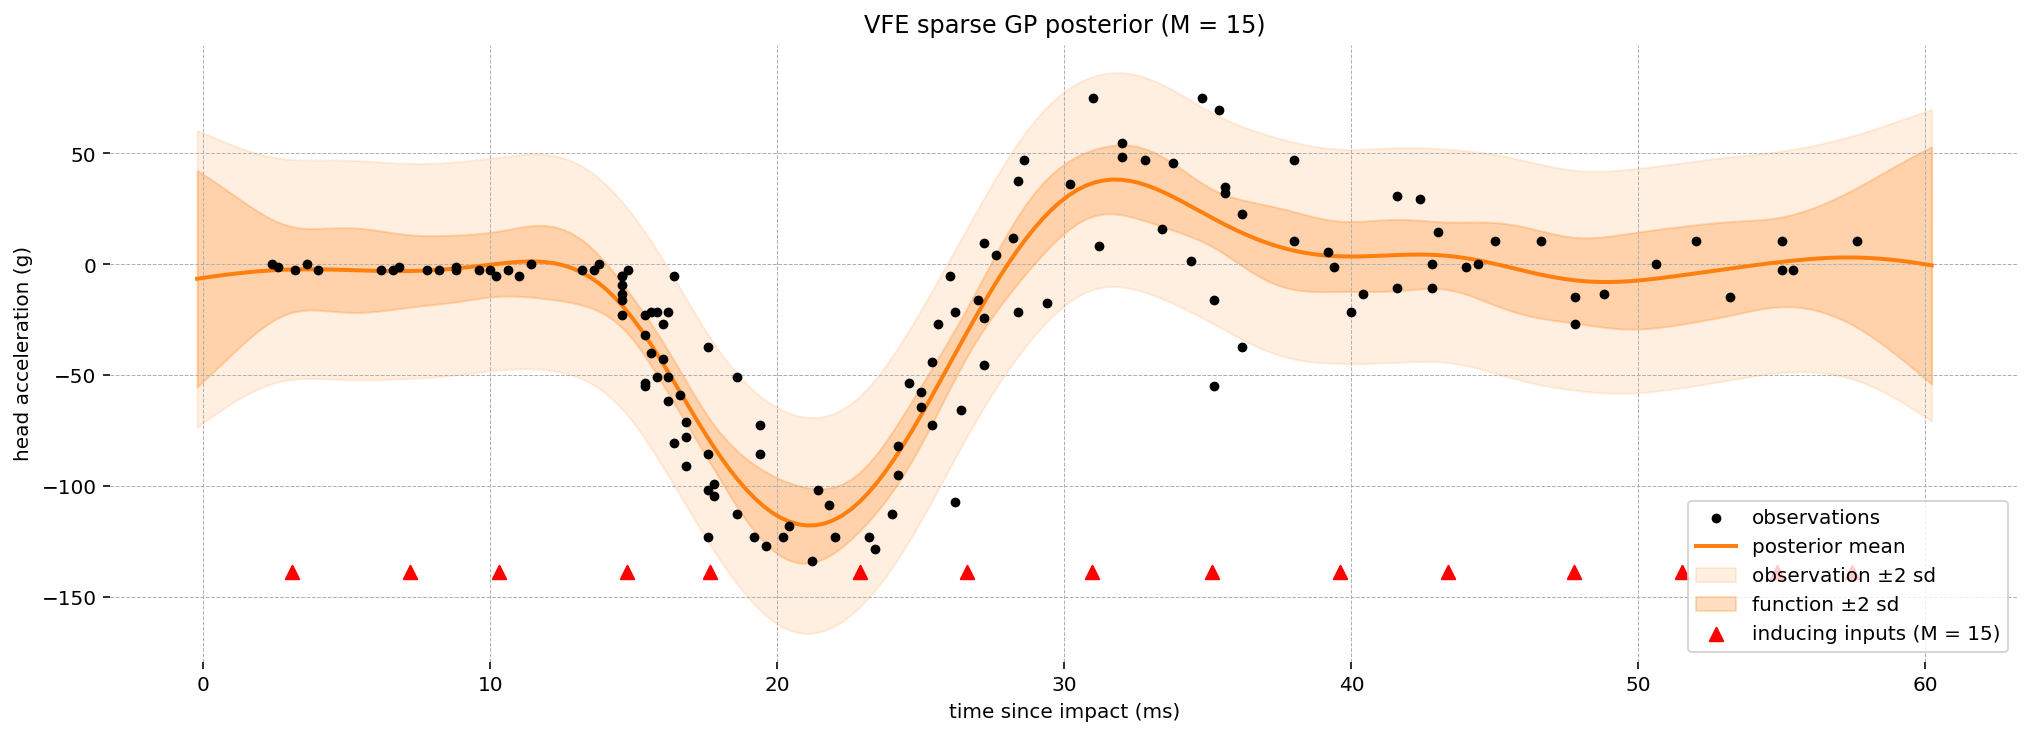

In [29]:
mu_v, var_v = pg.predict(vfe, X_grid, fit_vfe, X_train=X, y_train=y)
_, var_v_y = pg.predict(vfe, X_grid, fit_vfe, X_train=X, y_train=y, incl_lik=True)

sd_v, sd_v_y = np.sqrt(var_v), np.sqrt(var_v_y)
mean_v = to_g(mu_v)
f_band_v = to_g(mu_v - 2 * sd_v), to_g(mu_v + 2 * sd_v)
y_band_v = to_g(mu_v - 2 * sd_v_y), to_g(mu_v + 2 * sd_v_y)

Z_final = fit_vfe.shared_extras[0].get_value()  # inducing inputs after optimization
z_ms = x_scaler.inverse_transform(Z_final).ravel()

plot_gp(
    mean_v,
    f_band_v,
    y_band_v,
    color="C1",
    inducing=z_ms,
    title=f"VFE sparse GP posterior (M = {M})",
)
plt.show()

## Accuracy

With 15 inducing points against all 133 observations, the sparse posterior mean sits almost on top of the exact one.

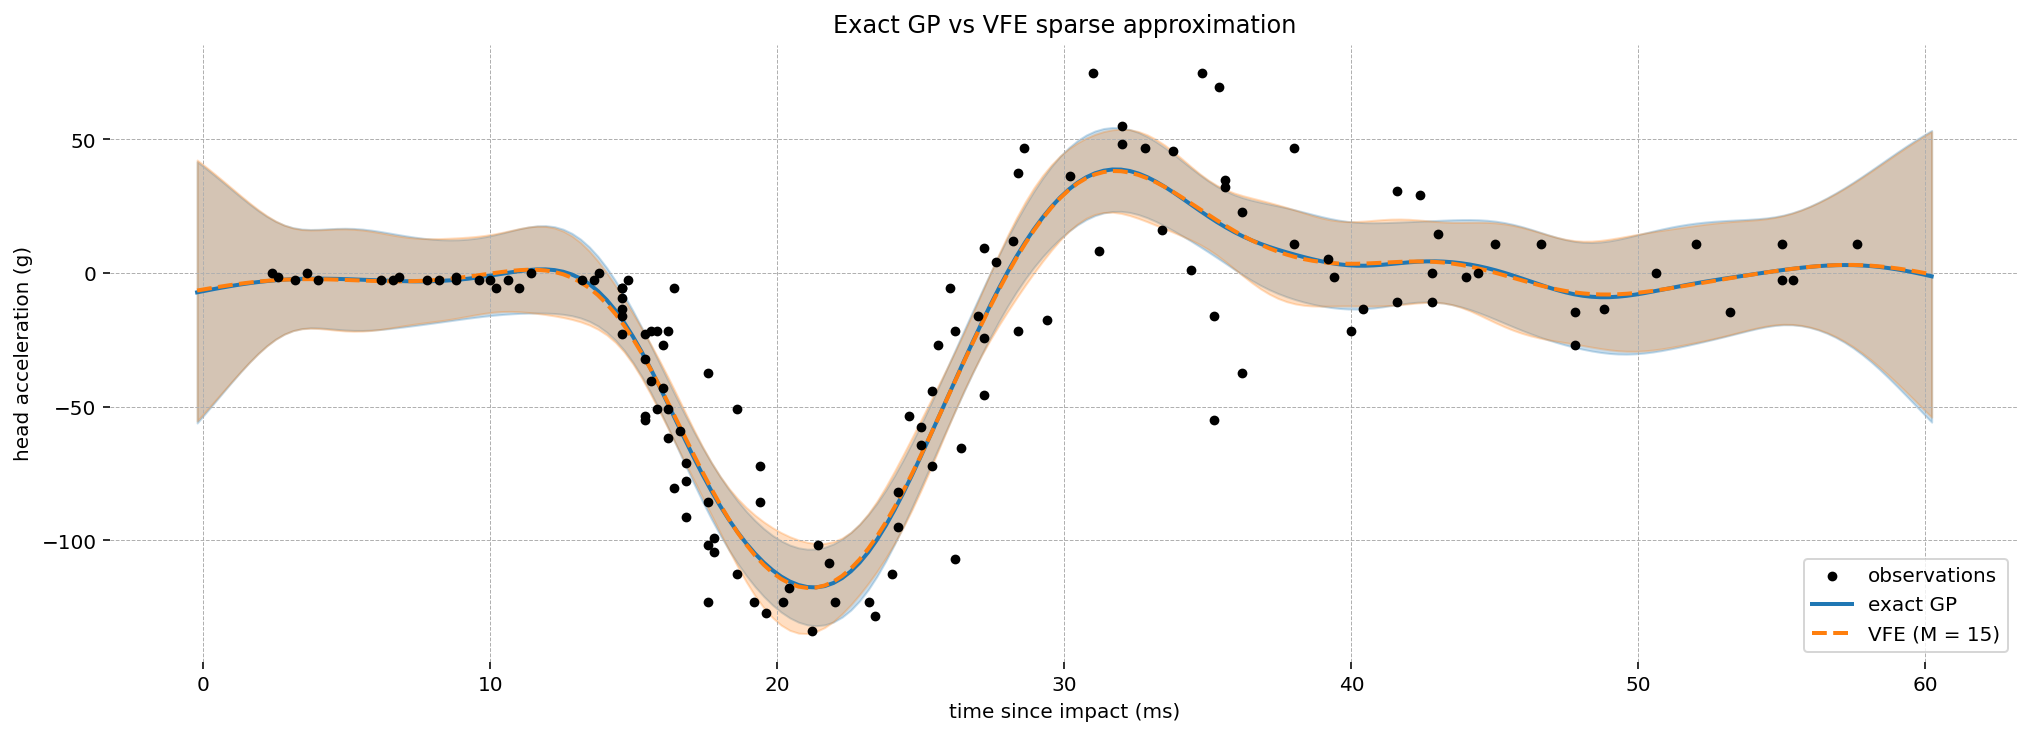

max |mean_VFE - mean_exact| = 1.50 g  (M = 15 inducing points vs all N = 133 observations)


In [30]:
ax = plot_gp(
    mean, f_band, label="exact GP", band_labels=False, title="Exact GP vs VFE sparse approximation"
)
plot_gp(mean_v, f_band_v, ax=ax, color="C1", ls="--", label=f"VFE (M = {M})", band_labels=False)
plt.show()

max_dev = np.max(np.abs(mean_v - mean))
print(
    f"max |mean_VFE - mean_exact| = {max_dev:.2f} g  "
    f"(M = {M} inducing points vs all N = {N} observations)"
)

## Next steps

- {doc}`Kernel gallery </kernels/gallery>`: covariance functions and what they encode.
- {doc}`User guide </user_guide/index>`: models, likelihoods, inducing points, and training.
- {ref}`Stochastic variational GPs <gp-variational-stochastic>`: SVGP, minibatching, non-Gaussian likelihoods, and Variational Fourier Features.

## References

```{bibliography}
```